In [13]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np


def read_in_weights(infile: str) -> tuple[np.ndarray, WCS]:
    """Reads in the data and WCS from the weights files"""
    hdu = fits.open(infile)
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
    hdu.close()
    return data, wcs


def mask_data(data: np.ndarray, limit: float) -> np.ndarray:
    """Creates a mask: 1 where data >= limit, 0 elsewhere"""
    mask = np.zeros_like(data, dtype=np.uint8)
    mask[data >= limit] = 1
    return mask


def create_weight_mask(weights: list[tuple]) -> tuple[np.ndarray, WCS]:
    """Creates the master weight mask which can be used for reducing sexcats"""
    masks = []
    for weight_file, limit in weights:
        data, wcs = read_in_weights(weight_file)
        mask = mask_data(data, limit)
        print(f"Weight file: {weight_file}")
        print(f"  Threshold: {limit}")
        print(f"  Pixels above threshold: {np.sum(mask)}")
        masks.append(mask)
    master_mask = masks[0] * masks[1] * masks[2]
    print("Total good pixels in master mask:", np.sum(master_mask))
    return master_mask, wcs


def mask_catalog(ra_array, dec_array, mask: np.ndarray, wcs: WCS) -> np.ndarray:
    """Determines which catalog sources fall on good pixels in the mask."""
    x_pix, y_pix = wcs.world_to_pixel_values(ra_array, dec_array)
    x_pix = x_pix.astype(int)
    y_pix = y_pix.astype(int)
    
    h, w = mask.shape
    valid = (x_pix >= 0) & (x_pix < w) & (y_pix >= 0) & (y_pix < h)
    x_pix = x_pix[valid]
    y_pix = y_pix[valid]
    
    good_mask = np.zeros(len(ra_array), dtype=bool)
    good_mask[valid] = mask[y_pix, x_pix] > 0
    return good_mask


def get_header_body(infile: str):
    """Splits the header and the body of text file."""
    with open(infile, encoding='utf8') as file:
        lines = file.readlines()

    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body


class Catalog:
    """Stores and edits catalog"""
    def __init__(self, sex_catalog: str, weights: list[tuple]):
        print(f"\nProcessing catalog: {sex_catalog}")
        self.sex_catalog = sex_catalog
        self.master_mask, self.wcs = create_weight_mask(weights)

        self.header, self.body = get_header_body(sex_catalog)

        # Load RA/Dec from columns 9 and 10 (0-based index → cols 8 and 9)
        self.ra_array, self.dec_array = np.loadtxt(self.sex_catalog, usecols=(3, 4), unpack=True)
        self.mask = mask_catalog(self.ra_array, self.dec_array, self.master_mask, self.wcs)

        print(f"Unmasked catalog entries: {np.sum(self.mask)} / {len(self.ra_array)}")

        self.reduce_body()
        self.write_catalog()

    def reduce_body(self):
        """Only selects rows that aren't masked"""
        self.body = list(np.array(self.body)[self.mask])

    def write_catalog(self):
        """Writes the current version of the catalog to file."""
        with open(self.sex_catalog.replace(".cat", "_masked.cat"), 'w', encoding='utf8') as file:
            for line in self.header:
                file.write(line)
            for line in self.body:
                file.write(line)


if __name__ == '__main__':
    WEIGHTS = [
        ('/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits', 0.0008),
        ('/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits', 0.001),
        ('/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits', 1.97e-3)
    ]

    SEX_CATALOGS = [
        '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_I.cat',
        '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Z.cat',
        '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y.cat'
    ]

    for sex_cat in SEX_CATALOGS:
        Catalog(sex_cat, WEIGHTS)


Processing catalog: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_I.cat
Weight file: /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits
  Threshold: 0.0008
  Pixels above threshold: 556075003
Weight file: /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits
  Threshold: 0.001
  Pixels above threshold: 548643227
Weight file: /Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits
  Threshold: 0.00197
  Pixels above threshold: 565639157
Total good pixels in master mask: 541180690
Unmasked catalog entries: 413526 / 517441

Processing catalog: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Z.cat
Weight file: /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits
  Threshold: 0.0008
  Pixels above threshold: 556075003
Weight file: /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits
  Threshold: 0.001
  Pixels above threshold: 548643

In [14]:
import numpy as np
import pyregion
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.path import Path
import matplotlib.pyplot as plt


def load_coords_radec(cat_file: str):
    """Load RA and Dec columns from SExtractor catalog.
    Using columns 7 (ALPHAPEAK_SKY) and 8 (DELTAPEAK_SKY), zero-based index 6 and 7."""
    data = np.loadtxt(cat_file, comments='#', usecols=(3, 4))
    ra = data[:, 0]
    dec = data[:, 1]
    return ra, dec


def radec_to_xy(ra, dec, wcs):
    """Convert RA, Dec arrays to pixel coordinates using WCS."""
    x, y = wcs.wcs_world2pix(ra, dec, 0)  # origin=0 for zero-based pixels
    return x, y


def get_header_body(cat_file: str):
    """Split catalog into header and data lines."""
    with open(cat_file, encoding='utf8') as f:
        lines = f.readlines()
    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body


def load_region_paths_pixel(region_file: str):
    """Load polygon regions from DS9 region file in pixel coordinates (format: 'physical')."""
    reg = pyregion.open(region_file)
    paths = []
    for r in reg:
        if r.name != 'polygon':
            print(f"Skipping non-polygon region: {r.name} in {region_file}")
            continue
        xy = np.array(r.coord_list).reshape(-1, 2)  # pixels
        path = Path(xy)
        paths.append(path)
    return paths


def mask_sources(x_array, y_array, region_paths: list):
    """Return boolean mask: True for sources *inside* any valid polygon region."""
    points = np.vstack((x_array, y_array)).T
    mask = np.zeros(len(x_array), dtype=bool)
    for path in region_paths:
        inside = path.contains_points(points)
        mask |= inside
    return mask


def update_catalog(cat_file: str, region_paths: list, fits_file: str):
    """Apply region mask and write new catalog with only kept sources."""
    # Load WCS
    wcs = WCS(fits_file)
    
    # Load RA, Dec from catalog
    ra, dec = load_coords_radec(cat_file)
    
    # Convert RA, Dec to pixels
    x, y = radec_to_xy(ra, dec, wcs)
    
    # Mask sources inside polygon(s)
    keep_mask = mask_sources(x, y, region_paths)
    
    header, body = get_header_body(cat_file)
    body = np.array(body)
    kept_body = body[keep_mask]

    out_file = cat_file.replace("_masked.cat", "_final.cat")

    with open(out_file, 'w', encoding='utf8') as f:
        for line in header:
            f.write(line)
        for line in kept_body:
            f.write(line)

    print(f"Updated {out_file}: kept {np.sum(keep_mask)} sources.")


def plot_sources_with_region(cat_file: str, fits_file: str, region_file: str):
    """Plot sources and polygon region for debugging."""
    wcs = WCS(fits_file)
    ra, dec = load_coords_radec(cat_file)
    x, y = radec_to_xy(ra, dec, wcs)
    data = fits.getdata(fits_file)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(data, origin='lower', cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 99))
    ax.scatter(x, y, s=10, edgecolor='cyan', facecolor='none', label='Sources')

    paths = load_region_paths_pixel(region_file)
    for path in paths:
        patch = plt.Polygon(path.vertices, edgecolor='red', facecolor='none', lw=2)
        ax.add_patch(patch)

    ax.set_title("Sources and region polygon")
    ax.legend()
    plt.show()


if __name__ == '__main__':
    REGION_FITS_MAP = {
        'i': ('/Users/aishwarya/Desktop/Lyman_alpha_2/Region_files/i.reg',
              '/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_mosaic_i.fits'),
        'y': ('/Users/aishwarya/Desktop/Lyman_alpha_2/Region_files/y_band.reg',
              '/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_mosaic_y.fits'),
        'z': ('/Users/aishwarya/Desktop/Lyman_alpha_2/Region_files/z.reg',
              '/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_mosaic_z.fits')
    }

    MASKED_CATALOGS = {
        'i': '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_I_masked.cat',
        'y': '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y_masked.cat',
        'z': '/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Z_masked.cat'
    }

    for band in ['i', 'y', 'z']:
        region_file, fits_file = REGION_FITS_MAP[band]
        region_paths = load_region_paths_pixel(region_file)
        update_catalog(MASKED_CATALOGS[band], region_paths, fits_file)

        print(f"Finished masking catalog for {band}.")

Updated /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_I_final.cat: kept 357630 sources.
Finished masking catalog for i.
Updated /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y_final.cat: kept 414747 sources.
Finished masking catalog for y.
Updated /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Z_final.cat: kept 401696 sources.
Finished masking catalog for z.


# Mask Negative pixels


# Inspection

In [9]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np


# ------------------------------------------------------------
# WEIGHT MAP UTILITIES
# ------------------------------------------------------------

def inspect_weight_file(infile: str):
    """Prints detailed diagnostics of a weight map."""
    with fits.open(infile) as hdul:
        print(f"\nInspecting {infile}")
        hdul.info()

        # Try HDU 0 first
        data = hdul[0].data
        header = hdul[0].header

        if data is None:
            print("  HDU 0 has no data, trying HDU 1")
            data = hdul[1].data
            header = hdul[1].header

        finite = np.isfinite(data)
        positive = data[finite & (data > 0)]

        print("  Shape:", data.shape)
        print("  NaNs:", np.isnan(data).sum())
        print("  Finite pixels:", finite.sum())

        if positive.size > 0:
            print("  Min (pos):", positive.min())
            print("  Max (pos):", positive.max())
            print("  Median (pos):", np.median(positive))
            print("  10th percentile:", np.percentile(positive, 10))
        else:
            print("  WARNING: No positive pixels found!")

        return data, header


def read_in_weights(infile: str):
    """Reads data and WCS safely (handles HDU 0/1)."""
    with fits.open(infile) as hdul:
        data = hdul[0].data
        header = hdul[0].header

        if data is None:
            data = hdul[1].data
            header = hdul[1].header

    return data, WCS(header)


def mask_data(data: np.ndarray, limit: float) -> np.ndarray:
    """Creates a binary mask from weight data."""
    mask = np.zeros(data.shape, dtype=np.uint8)
    good = np.isfinite(data) & (data >= limit)
    mask[good] = 1
    return mask


def create_weight_mask(weights: list[tuple]) -> tuple[np.ndarray, WCS]:
    """Creates the combined master weight mask."""
    masks = []
    wcs_out = None

    for weight_file, limit in weights:
        data, wcs = read_in_weights(weight_file)
        mask = mask_data(data, limit)

        print(f"\nWeight file: {weight_file}")
        print(f"  Threshold: {limit}")
        print(f"  Pixels above threshold: {mask.sum()} / {mask.size}")

        if mask.sum() == 0:
            print("  ❌ WARNING: No pixels pass this threshold!")

        masks.append(mask)
        wcs_out = wcs  # assume all aligned

    master_mask = masks[0]
    for m in masks[1:]:
        master_mask *= m

    print("\nTotal good pixels in MASTER mask:", master_mask.sum())
    return master_mask, wcs_out


# ------------------------------------------------------------
# CATALOG UTILITIES
# ------------------------------------------------------------

def mask_catalog(ra, dec, mask: np.ndarray, wcs: WCS) -> np.ndarray:
    """Returns boolean mask for catalog objects."""
    x, y = wcs.world_to_pixel_values(ra, dec)
    x = x.astype(int)
    y = y.astype(int)

    h, w = mask.shape
    valid = (x >= 0) & (x < w) & (y >= 0) & (y < h)

    good = np.zeros(len(ra), dtype=bool)
    good[valid] = mask[y[valid], x[valid]] > 0
    return good


def get_header_body(infile: str):
    with open(infile, encoding="utf8") as f:
        lines = f.readlines()

    header = [l for l in lines if l.startswith("#")]
    body = [l for l in lines if not l.startswith("#")]
    return header, body


# ------------------------------------------------------------
# MAIN CATALOG CLASS
# ------------------------------------------------------------

class Catalog:
    def __init__(self, sex_catalog: str, weights: list[tuple]):
        print(f"\n==============================")
        print(f"Processing catalog: {sex_catalog}")

        self.master_mask, self.wcs = create_weight_mask(weights)
        self.header, self.body = get_header_body(sex_catalog)

        self.ra, self.dec = np.loadtxt(
            sex_catalog, usecols=(3, 4), unpack=True
        )

        self.keep = mask_catalog(self.ra, self.dec, self.master_mask, self.wcs)

        print(f"Unmasked catalog entries: {self.keep.sum()} / {len(self.keep)}")

        self.body = list(np.array(self.body)[self.keep])
        self.write_catalog(sex_catalog)

    def write_catalog(self, infile):
        outfile = infile.replace(".cat", "_masked.cat")
        with open(outfile, "w", encoding="utf8") as f:
            f.writelines(self.header)
            f.writelines(self.body)

        print(f"Written: {outfile}")


# ------------------------------------------------------------
# RUN SCRIPT
# ------------------------------------------------------------

if __name__ == "__main__":

    WEIGHTS = [
        ("/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits", 0.0008),
        ("/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits", 0.008),
        ("/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits", 0.0037),
    ]

    # 🔍 INSPECT ALL WEIGHTS FIRST
    for wf, _ in WEIGHTS:
        inspect_weight_file(wf)

    SEX_CATALOGS = [
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_I.cat",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Z.cat",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/LBG_Y_Y.cat",
    ]

    for cat in SEX_CATALOGS:
        Catalog(cat, WEIGHTS)



Inspecting /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits
Filename: /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      22   (26667, 26667)   float32   
  Shape: (26667, 26667)
  NaNs: 0
  Finite pixels: 711128889
  Min (pos): 2.2041417e-11
  Max (pos): 0.0016917345
  Median (pos): 0.000891613


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pyregion
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.path import Path
import matplotlib.pyplot as plt


def sanity_check(cat_file, fits_file, region_file,
                 ra_col=3, dec_col=4):
    print("\n" + "="*80)
    print("SANITY CHECK")
    print("="*80)

    # ------------------------------------------------------------------
    # 1. Load catalog RA/Dec
    # ------------------------------------------------------------------
    try:
        data = np.loadtxt(cat_file, comments="#", usecols=(ra_col, dec_col))
        ra = data[:, 0]
        dec = data[:, 1]
        print(f"[OK] Loaded {len(ra)} sources from catalog")
        print("RA range :", ra.min(), ra.max())
        print("Dec range:", dec.min(), dec.max())
    except Exception as e:
        print("[FAIL] Could not read RA/Dec columns")
        print(e)
        return

    # ------------------------------------------------------------------
    # 2. Load FITS + WCS
    # ------------------------------------------------------------------
    try:
        hdu = fits.open(fits_file)
        data_img = hdu[0].data
        wcs = WCS(hdu[0].header)
        ny, nx = data_img.shape
        print(f"[OK] FITS loaded, image shape: {nx} x {ny}")
    except Exception as e:
        print("[FAIL] FITS/WCS problem")
        print(e)
        return

    # ------------------------------------------------------------------
    # 3. Convert RA/Dec → pixels
    # ------------------------------------------------------------------
    try:
        x, y = wcs.wcs_world2pix(ra, dec, 0)
        print("[OK] RA/Dec → pixel conversion")
        print("X range:", np.nanmin(x), np.nanmax(x))
        print("Y range:", np.nanmin(y), np.nanmax(y))

        inside_image = (
            (x >= 0) & (x < nx) &
            (y >= 0) & (y < ny)
        )
        print(f"Sources inside image: {inside_image.sum()} / {len(x)}")
    except Exception as e:
        print("[FAIL] WCS conversion failed")
        print(e)
        return

    # ------------------------------------------------------------------
    # 4. Load region and inspect polygon bounds
    # ------------------------------------------------------------------
    try:
        reg = pyregion.open(region_file)
        paths = []

        for r in reg:
            if r.name != "polygon":
                continue

            coords = np.array(r.coord_list).reshape(-1, 2)
            paths.append(Path(coords))

            print("[OK] Region polygon loaded")
            print("Polygon X range:",
                  coords[:, 0].min(), coords[:, 0].max())
            print("Polygon Y range:",
                  coords[:, 1].min(), coords[:, 1].max())

            if coords[:, 0].max() > nx or coords[:, 1].max() > ny:
                print("⚠ WARNING: Polygon extends outside image bounds")

        if not paths:
            print("[FAIL] No polygon found in region file")
            return

    except Exception as e:
        print("[FAIL] Region file problem")
        print(e)
        return

    # ------------------------------------------------------------------
    # 5. Test point-in-polygon logic
    # ------------------------------------------------------------------
    points = np.vstack((x, y)).T
    mask = np.zeros(len(points), dtype=bool)

    for path in paths:
        mask |= path.contains_points(points)

    print(f"Sources inside region: {mask.sum()} / {len(mask)}")

    if mask.sum() == 0:
        print("❌ ZERO sources inside polygon → masking WILL FAIL")
    else:
        print("✅ Masking should work")

    # ------------------------------------------------------------------
    # 6. Visual confirmation plot
    # ------------------------------------------------------------------
    print("Displaying diagnostic plot...")
    plt.figure(figsize=(8, 8))
    plt.imshow(data_img, origin="lower", cmap="gray",
               vmin=np.percentile(data_img, 5),
               vmax=np.percentile(data_img, 99))

    plt.scatter(x, y, s=1, c="cyan", label="All sources")

    for path in paths:
        plt.plot(path.vertices[:, 0],
                 path.vertices[:, 1],
                 "r-", lw=2)

    plt.legend()
    plt.title("Sanity check: sources + region")
    plt.show()


# ----------------------------------------------------------------------
# RUN FOR Z BAND (change columns if needed)
# ----------------------------------------------------------------------
if __name__ == "__main__":

    sanity_check(
        cat_file="/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_masked.cat",
        fits_file="/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_mosaic_z.fits",
        region_file="/Users/aishwarya/Desktop/Lyman_alpha_2/Region_files/z.reg",
        ra_col=3,   # TRY 6 if this fails
        dec_col=4
    )



SANITY CHECK
[OK] Loaded 490316 sources from catalog
RA range : 355.9722707 358.3051595
Dec range: -31.821612 -29.8206556
[OK] FITS loaded, image shape: 26667 x 26667
[OK] RA/Dec → pixel conversion
X range: -0.0005090627637400758 26665.99964867322
Y range: 0.31933744626803673 26666.00060999355
Sources inside image: 490314 / 490316
[OK] Region polygon loaded
Polygon X range: 263.94336 26461.303
Polygon Y range: 104.20336 26434.68
Sources inside region: 384668 / 490316
✅ Masking should work
Displaying diagnostic plot...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import os


def cat_to_reg(cat_file, ra_col=3, dec_col=4,
               point_style="circle", point_size=5):
    """
    Convert a SExtractor .cat file to a DS9 .reg file (FK5).

    Parameters
    ----------
    cat_file : str
        Path to input .cat file
    ra_col : int
        Zero-based RA column index
    dec_col : int
        Zero-based Dec column index
    point_style : str
        DS9 point style (circle, cross, x, diamond)
    point_size : int
        Point size
    """

    # Output .reg file name
    reg_file = cat_file.replace(".cat", ".reg")

    # Load RA/Dec
    data = np.loadtxt(cat_file, comments="#", usecols=(ra_col, dec_col))
    ra = data[:, 0]
    dec = data[:, 1]

    with open(reg_file, "w", encoding="utf8") as f:
        # DS9 header
        f.write("# Region file format: DS9 version 4.1\n")
        f.write("global color=cyan width=2\n")
        f.write("fk5\n")

        # Write sources
        for r, d in zip(ra, dec):
            f.write(
                f"point({r},{d}) # point={point_style} {point_size}\n"
            )

    print(f"Created DS9 region file: {reg_file}")


if __name__ == "__main__":

    CAT_FILES = [
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band1_final.cat",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/y_band1_final.cat",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_masked.cat"
    ]

    for cat in CAT_FILES:
        if not os.path.exists(cat):
            print(f"File not found: {cat}")
            continue

        cat_to_reg(
            cat_file=cat,
            ra_col=3,   # RA column (zero-based)
            dec_col=4   # Dec column (zero-based)
        )

    print("All catalogs converted to DS9 region files.")


Created DS9 region file: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/i_band1_final.reg
Created DS9 region file: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/y_band1_final.reg
Created DS9 region file: /Users/aishwarya/Desktop/Lyman_alpha_2/CAT/z_band_masked.reg
All catalogs converted to DS9 region files.


In [ ]:
import numpy as np
import pyregion
from astropy.io import fits
from astropy.wcs import WCS
from matplotlib.path import Path


def load_coords_radec(cat_file: str):
    """Load RA and Dec columns from SExtractor catalog (columns 4 and 5)."""
    data = np.loadtxt(cat_file, comments='#', usecols=(3, 4))
    return data[:, 0], data[:, 1]  # RA, Dec


def radec_to_xy(ra, dec, wcs):
    """Convert RA, Dec arrays to pixel coordinates using WCS."""
    x, y = wcs.wcs_world2pix(ra, dec, 0)
    return x, y


def get_header_body(cat_file: str):
    """Split catalog into header and data lines."""
    with open(cat_file, encoding='utf8') as f:
        lines = f.readlines()
    header = [line for line in lines if line.startswith('#')]
    body = [line for line in lines if not line.startswith('#')]
    return header, body


def load_region_paths_pixel(region_file: str):
    """Load polygon regions from DS9 region file in pixel coordinates (physical)."""
    reg = pyregion.open(region_file)
    paths = []
    for r in reg:
        if r.name != 'polygon':
            print(f"Skipping non-polygon region: {r.name} in {region_file}")
            continue
        xy = np.array(r.coord_list).reshape(-1, 2)  # (x,y) pixel coords
        paths.append(Path(xy))
    return paths


def mask_sources(x_array, y_array, region_paths: list):
    """Return boolean mask: True for sources inside any polygon region."""
    points = np.vstack((x_array, y_array)).T
    mask = np.zeros(len(x_array), dtype=bool)
    for path in region_paths:
        mask |= path.contains_points(points)
    return mask


def apply_nb_mask(cat_file: str, fits_file: str, region_paths: list, suffix="_nbmasked.cat"):
    """Mask OUT sources inside NB964 polygons and save new file."""
    wcs = WCS(fits_file)

    ra, dec = load_coords_radec(cat_file)
    x, y = radec_to_xy(ra, dec, wcs)

    inside_mask = mask_sources(x, y, region_paths)
    keep_mask = ~inside_mask   # invert -> keep sources OUTSIDE the polygons

    header, body = get_header_body(cat_file)
    body = np.array(body)
    kept_body = body[keep_mask]

    out_file = cat_file.replace(".cat", suffix)

    with open(out_file, 'w', encoding='utf8') as f:
        for line in header:
            f.write(line)
        for line in kept_body:
            f.write(line)

    print(f"NB mask applied to {cat_file}: removed {np.sum(inside_mask)} sources, kept {np.sum(keep_mask)} -> {out_file}")


if __name__ == '__main__':
    # --- Paths ---
    NB_REGION_FILE = "/Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg"

    MASKED_CATALOGS = {
        'i': '/Users/aishwarya/Documents/Lyman_alpha/CAT/i_band_final.cat',
        'n964': '/Users/aishwarya/Documents/Lyman_alpha/CAT/n964_band_final.cat',
        'z': '/Users/aishwarya/Documents/Lyman_alpha/CAT/z_band_final.cat'
    }

    FITS_FILES = {
        'i': '/Users/aishwarya/Documents/Lyman_alpha/I/mosaic_i_cut.fits',
        'n964': '/Users/aishwarya/Documents/Lyman_alpha/N964/mosaic_N964_cut.fits',
        'z': '/Users/aishwarya/Documents/Lyman_alpha/Z/mosaic_z_cut.fits'
    }

    # --- Load NB964 polygon regions ---
    nb_region_paths = load_region_paths_pixel(NB_REGION_FILE)

    # --- Apply same NB mask to all bands ---
    for band in ['i', 'n964', 'z']:
        apply_nb_mask(MASKED_CATALOGS[band], FITS_FILES[band], nb_region_paths)


Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aishwarya/Documents/Lyman_alpha/CAT/mask_bad.reg
Skipping non-polygon region: circle in /Users/aish

#   MASKED FITS

In [ ]:
import numpy as np
from astropy.io import fits
import pyregion
from matplotlib.path import Path


# ----------------------------------------------------
# Load DS9 polygon regions (in pixel/physical coords)
# ----------------------------------------------------
def load_region_paths_pixel(region_file):
    reg = pyregion.open(region_file)
    paths = []

    for r in reg:
        if r.name != "polygon":
            print(f"Skipping non-polygon region: {r.name}")
            continue

        xy = np.array(r.coord_list).reshape(-1, 2)
        paths.append(Path(xy))

    return paths


# ----------------------------------------------------
# Create masked FITS (outside polygon = NaN)
# ----------------------------------------------------
def create_fits_mask(fits_file, region_file, output_file=None, fill_value=np.nan):
    # Load FITS
    with fits.open(fits_file) as hdul:
        data = hdul[0].data.copy()
        header = hdul[0].header

    ny, nx = data.shape

    # Pixel coordinate grid
    yy, xx = np.mgrid[0:ny, 0:nx]
    coords = np.vstack((xx.ravel(), yy.ravel())).T

    # Load region polygons
    region_paths = load_region_paths_pixel(region_file)

    # Mask for pixels inside region(s)
    keep_mask = np.zeros(coords.shape[0], dtype=bool)
    for path in region_paths:
        inside = path.contains_points(coords)
        keep_mask |= inside

    keep_mask = keep_mask.reshape(ny, nx)

    # Apply mask (outside = fill_value)
    masked_data = data.copy()
    masked_data[~keep_mask] = fill_value

    # Output name
    if output_file is None:
        output_file = fits_file.replace(".fits", "_masked.fits")

    # Write file
    fits.PrimaryHDU(masked_data, header).writeto(output_file, overwrite=True)

    print(f" Masked FITS saved: {output_file}")
    print(f"   Kept pixels:  {keep_mask.sum()}")
    print(f"   Masked pixels: {(~keep_mask).sum()}\n")

    return output_file


# ----------------------------------------------------
# Run for all three mosaics
# ----------------------------------------------------
if __name__ == "__main__":

    FILES = {
        "i": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_i_new.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/i.reg"
        },
        "n964": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_N964_new.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/N964.reg"
        },
        "z": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_z2_cut.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/Z.reg"
        }
    }

    for band, paths in FILES.items():
        print(f"--- Processing {band}-band ---")
        create_fits_mask(
            fits_file=paths["fits"],
            region_file=paths["reg"]
        )

    print(" All masked FITS files created successfully.")


--- Processing i-band ---
 Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_i_new_masked.fits
   Kept pixels:  531564618
   Masked pixels: 179777623

--- Processing n964-band ---
 Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_N964_new_masked.fits
   Kept pixels:  525959684
   Masked pixels: 185329216

--- Processing z-band ---
Skipping non-polygon region: circle
 Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_z2_cut_masked.fits
   Kept pixels:  535722165
   Masked pixels: 175620076

 All masked FITS files created successfully.


In [ ]:
import numpy as np
from astropy.io import fits
import pyregion
from matplotlib.path import Path


# ----------------------------------------------------
# Load DS9 polygon regions (in pixel/physical coords)
# ----------------------------------------------------
def load_region_paths_pixel(region_file):
    reg = pyregion.open(region_file)
    paths = []

    for r in reg:
        if r.name != "polygon":
            print(f"Skipping non-polygon region: {r.name}")
            continue

        xy = np.array(r.coord_list).reshape(-1, 2)
        paths.append(Path(xy))

    return paths


# ----------------------------------------------------
# Create masked FITS (outside polygon = fill_value)
# ----------------------------------------------------
def create_fits_mask(fits_file, region_file, output_file=None, fill_value=np.nan):
    # Load FITS
    with fits.open(fits_file) as hdul:
        data = hdul[0].data.copy()
        header = hdul[0].header

    ny, nx = data.shape

    # Pixel coordinate grid
    yy, xx = np.mgrid[0:ny, 0:nx]
    coords = np.vstack((xx.ravel(), yy.ravel())).T

    # Load region polygons
    region_paths = load_region_paths_pixel(region_file)

    # Mask for pixels inside region(s)
    keep_mask = np.zeros(coords.shape[0], dtype=bool)
    for path in region_paths:
        inside = path.contains_points(coords)
        keep_mask |= inside

    keep_mask = keep_mask.reshape(ny, nx)

    # Apply mask (outside = fill_value)
    masked_data = data.copy()
    masked_data[~keep_mask] = fill_value

    # Output name
    if output_file is None:
        output_file = fits_file.replace(".fits", "_masked.fits")

    fits.PrimaryHDU(masked_data, header).writeto(output_file, overwrite=True)

    print(f"✔ Masked FITS saved: {output_file}")
    print(f"   Kept pixels:  {keep_mask.sum()}")
    print(f"   Masked pixels: {(~keep_mask).sum()}\n")

    return output_file


# ----------------------------------------------------
# MAIN EXECUTION
# ----------------------------------------------------
if __name__ == "__main__":

    # Science images + region files
    FILES = {
        "i": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_i_new.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/i.reg",
            "wgt": "/Users/aishwarya/Documents/Lyman_alpha/i_WEIGHT/fits/weight_mosaic_itrim.fits",
            "wgt_fill": 0.0008
        },
        "n964": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_N964_new.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/N964.reg",
            "wgt": "/Users/aishwarya/Documents/Lyman_alpha/N964_WEIGHT/New/weight_mosaic_N964trim.fits",
            "wgt_fill": 0.001
        },
        "z": {
            "fits": "/Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_z2_cut.fits",
            "reg":  "/Users/aishwarya/Documents/Lyman_alpha/region files/Z.reg",
            "wgt": "/Users/aishwarya/Documents/Lyman_alpha/Z_WEIGHT/New/weight_mosaic_ztrim.fits",
            "wgt_fill": 0.0008
        }
    }

    # Process each band
    for band, item in FILES.items():

        region_file = item["reg"]
        science_fits = item["fits"]
        weight_fits = item["wgt"]
        weight_fill = item["wgt_fill"]

        print(f"\n--- Processing {band}-band ---")

        # 1️⃣ Mask the SCIENCE image (outside = NaN)
        create_fits_mask(
            fits_file=science_fits,
            region_file=region_file,
            fill_value=np.nan,
            output_file=science_fits.replace(".fits", "_masked.fits")
        )

        # 2️⃣ Mask the WEIGHT image (outside = assigned value)
        create_fits_mask(
            fits_file=weight_fits,
            region_file=region_file,
            fill_value=weight_fill,
            output_file=weight_fits.replace(".fits", "_masked.fits")
        )

    print("\n All science and weight FITS files masked successfully.\n")



--- Processing i-band ---
✔ Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_i_new_masked.fits
   Kept pixels:  531564618
   Masked pixels: 179777623

✔ Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/i_WEIGHT/fits/weight_mosaic_itrim_masked.fits
   Kept pixels:  531564618
   Masked pixels: 179777623


--- Processing n964-band ---
✔ Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_N964_new_masked.fits
   Kept pixels:  525959684
   Masked pixels: 185329216

✔ Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/N964_WEIGHT/New/weight_mosaic_N964trim_masked.fits
   Kept pixels:  525959684
   Masked pixels: 185382557


--- Processing z-band ---
Skipping non-polygon region: circle
✔ Masked FITS saved: /Users/aishwarya/Documents/Lyman_alpha/Mosaic_images/mosaic_z2_cut_masked.fits
   Kept pixels:  535722165
   Masked pixels: 175620076

Skipping non-polygon region: circle
✔ Masked FITS saved: /Users/aishwarya/Document

Total pixels: 711128889
Good pixels: 638385581

Y-band weight statistics:
Median weight     : 3.937e-03
16–84 percentile  : 3.725e-03 – 4.066e-03

Suggested Y-band weight thresholds:
very_loose (mask only)   : 0.000e+00
recommended (0.5×med)    : 1.969e-03
clean (0.7×med)          : 2.756e-03
uniform (0.9×med)        : 3.543e-03


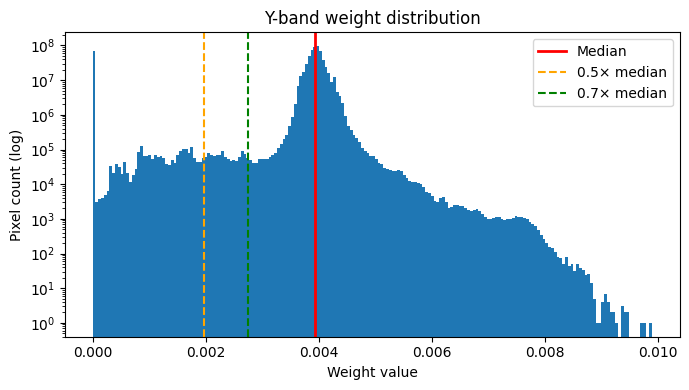

In [10]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

# ============================================================
# INPUT: Y-band weight map
# ============================================================
weight_file = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits"

# ============================================================
# READ WEIGHT IMAGE
# ============================================================
with fits.open(weight_file) as hdul:
    weight = hdul[0].data.astype(float)

# ============================================================
# CLEAN WEIGHTS
# ============================================================
# Keep only finite, positive weights
good_weights = weight[np.isfinite(weight) & (weight > 0)]

print("Total pixels:", weight.size)
print("Good pixels:", good_weights.size)

# ============================================================
# STATISTICS
# ============================================================
median_w = np.median(good_weights)
p16, p84 = np.percentile(good_weights, [16, 84])

print("\nY-band weight statistics:")
print(f"Median weight     : {median_w:.3e}")
print(f"16–84 percentile  : {p16:.3e} – {p84:.3e}")

# ============================================================
# RECOMMENDED THRESHOLDS
# ============================================================
thresholds = {
    "very_loose (mask only)": 0.0,
    "recommended (0.5×med)": 0.5 * median_w,
    "clean (0.7×med)"       : 0.7 * median_w,
    "uniform (0.9×med)"     : 0.9 * median_w,
}

print("\nSuggested Y-band weight thresholds:")
for k, v in thresholds.items():
    print(f"{k:25s}: {v:.3e}")

# ============================================================
# OPTIONAL: HISTOGRAM (highly recommended)
# ============================================================
plt.figure(figsize=(7, 4))
plt.hist(good_weights, bins=200, log=True)
plt.axvline(median_w, color="r", lw=2, label="Median")
plt.axvline(0.5 * median_w, color="orange", ls="--", label="0.5× median")
plt.axvline(0.7 * median_w, color="green", ls="--", label="0.7× median")
plt.xlabel("Weight value")
plt.ylabel("Pixel count (log)")
plt.title("Y-band weight distribution")
plt.legend()
plt.tight_layout()
plt.show()
